## Baseline Model
### Importing libraries and checking GPUS

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os

# Check if TensorFlow detects a GPU
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"GPU detected: {physical_devices}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


### Setup Data Generators

Instead of loading all images into RAM, we use TensorFlow's image_dataset_from_directory. This highly efficient tool pulls batches of images directly from your hard drive, passing them to the model during training.

Notice that we take your Training folder and split it: 80% is used to actually train the network, and 20% is held back as a "Validation" set to check the model's performance at the end of every epoch.

In [2]:
# Define paths to your cleaned data
TRAIN_DIR = r'E:\fourth_sem\brain_tumor_detection\datasets\03_processed\Training'
TEST_DIR = r'E:\fourth_sem\brain_tumor_detection\datasets\03_processed\Testing'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading Training and Validation Data...")
# Load Training Data (80% of the Training folder)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # Because we have 4 distinct classes
)

# Load Validation Data (20% of the Training folder)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Load Testing Data (100% of the Testing folder)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Extract class names for later use
class_names = train_dataset.class_names
print(f"Classes detected: {class_names}")

# Optimize data loading performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Loading Training and Validation Data...
Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes detected: ['glioma', 'meningioma', 'notumor', 'pituitary']


### Define the Baseline CNN Architecture

In [3]:
def build_baseline_model(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        # Data Augmentation directly inside the model
        layers.RandomFlip("horizontal", input_shape=input_shape),
        layers.RandomRotation(0.1),
        
        # Rescaling pixel values from [0, 255] to [0, 1]
        layers.Rescaling(1./255),
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Flatten and Final Classification
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting by randomly turning off neurons
        layers.Dense(num_classes, activation='softmax') # Softmax outputs percentages for each class
    ])
    
    return model

num_classes_detected = len(class_names) 
print(f"Building model for {num_classes_detected} classes: {class_names}")

# Pass that dynamic number into the model
baseline_model = build_baseline_model(num_classes=num_classes_detected)
baseline_model.summary()

Building model for 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

e:\fourth_sem\brain_tumor_detection\brain_env\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and Setup Callbacks
Callbacks are a hallmark of good coding. EarlyStopping prevents your model from training forever if it has stopped learning, and ModelCheckpoint ensures you automatically save the weights with the absolute best validation accuracy.

In [4]:
# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define where to save the best model weights
os.makedirs('../saved_models', exist_ok=True)
checkpoint_path = '../saved_models/baseline_model.keras'

# Setup callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1)
]

### Train the Model
This is where the actual learning happens. We will set it to 20 epochs, but thanks to EarlyStopping, it will likely stop sooner if it reaches its peak performance.

In [5]:
EPOCHS = 20

print("Starting training...")
history = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

Starting training...
Epoch 1/20


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3845 - loss: 1.2815
Epoch 1: val_accuracy improved from None to 0.74911, saving model to ../saved_models/baseline_model.keras

Epoch 1: finished saving model to ../saved_models/baseline_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.5029 - loss: 1.0817 - val_accuracy: 0.7491 - val_loss: 0.6555
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6685 - loss: 0.8284
Epoch 2: val_accuracy improved from 0.74911 to 0.79464, saving model to ../saved_models/baseline_model.keras

Epoch 2: finished saving model to ../saved_models/baseline_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.6886 - loss: 0.7757 - val_accuracy: 0.7946 - val_loss: 0.5424
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7358 - loss: 0.6749
Epoch 3: val_accuracy improved from 0.79464 to 0.80804, saving model to ../saved_models/baseline_model.keras

Epoch 3: finished saving model to ../saved_models/b

### Visualizing the training history

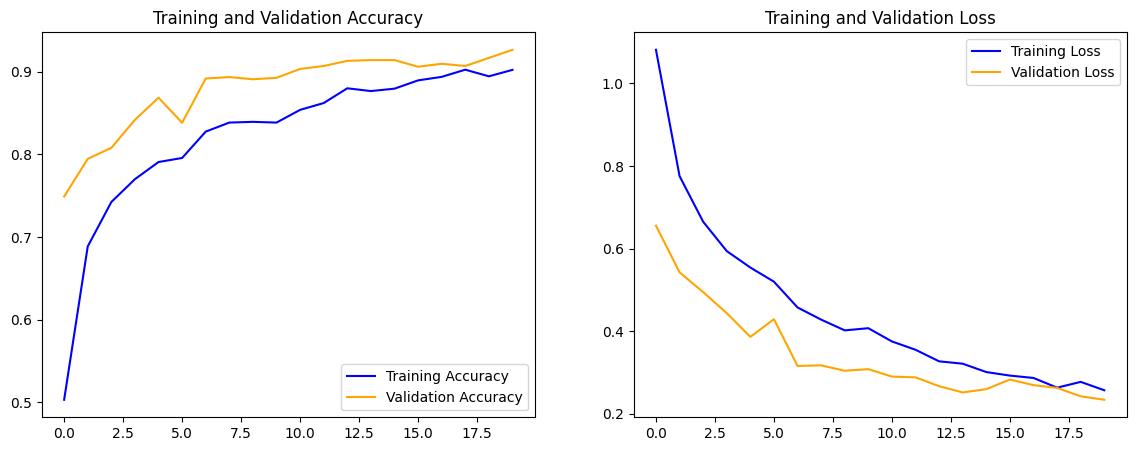

In [6]:
# Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()